In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV, cross_validate, cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.neural_network import MLPClassifier


# Mushroom Classification — EDA & Random Forest with Pipeline

## Data Exploration

This dataset comes from the UCI Machine Learning Repository.

It contains 8124 mushroom samples, 22 features describing the mushroom, and the class "edible" or "poisonous."


Attribute Information: (classes: edible=e, poisonous=p)

    - cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

    - cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

    - cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

    - bruises: bruises=t,no=f

    - odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

    - gill-attachment: attached=a,descending=d,free=f,notched=n

    - gill-spacing: close=c,crowded=w,distant=d

    - gill-size: broad=b,narrow=n

    - gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

    - stalk-shape: enlarging=e,tapering=t

    - stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

    - stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

    - stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

    - stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

    - stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

    - veil-type: partial=p,universal=u

    - veil-color: brown=n,orange=o,white=w,yellow=y

    - ring-number: none=n,one=o,two=t

    - ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

    - spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

    - population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

    - habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

### Data download

In [2]:
#Download data
mush_path = 'data/Mushrooms.csv'

mush_df = pd.read_csv(mush_path)

mush_df = mush_df.dropna()

print(mush_df.shape)
mush_df.head()


(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Some characteristics of our data

([<matplotlib.axis.XTick at 0x1d98b315b50>,
 [Text(0.16666666666666666, 0, 'Edible'),
  Text(0.8333333333333334, 0, 'Poisonous')])

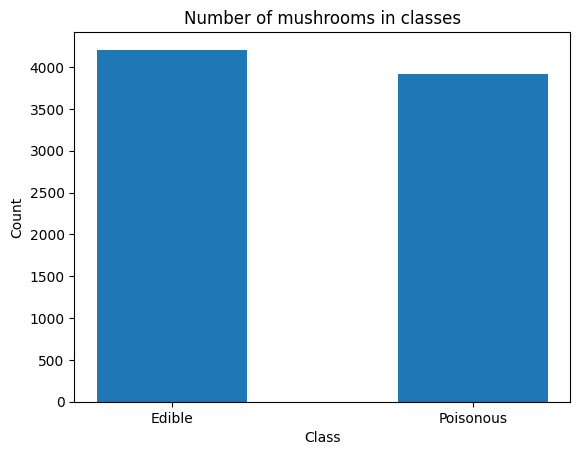

In [3]:
# to have 1 for poisonous and 0 for edible
mush_class = (mush_df['class'] == 'p').astype(int)

mush_class.hist(bins = 3)
plt.grid()
plt.title('Number of mushrooms in classes')
plt.ylabel('Count')
plt.xlabel('Class')
plt.xticks([1/6,5/6],['Edible', 'Poisonous'])

that shows us the classes of data are equilibrate

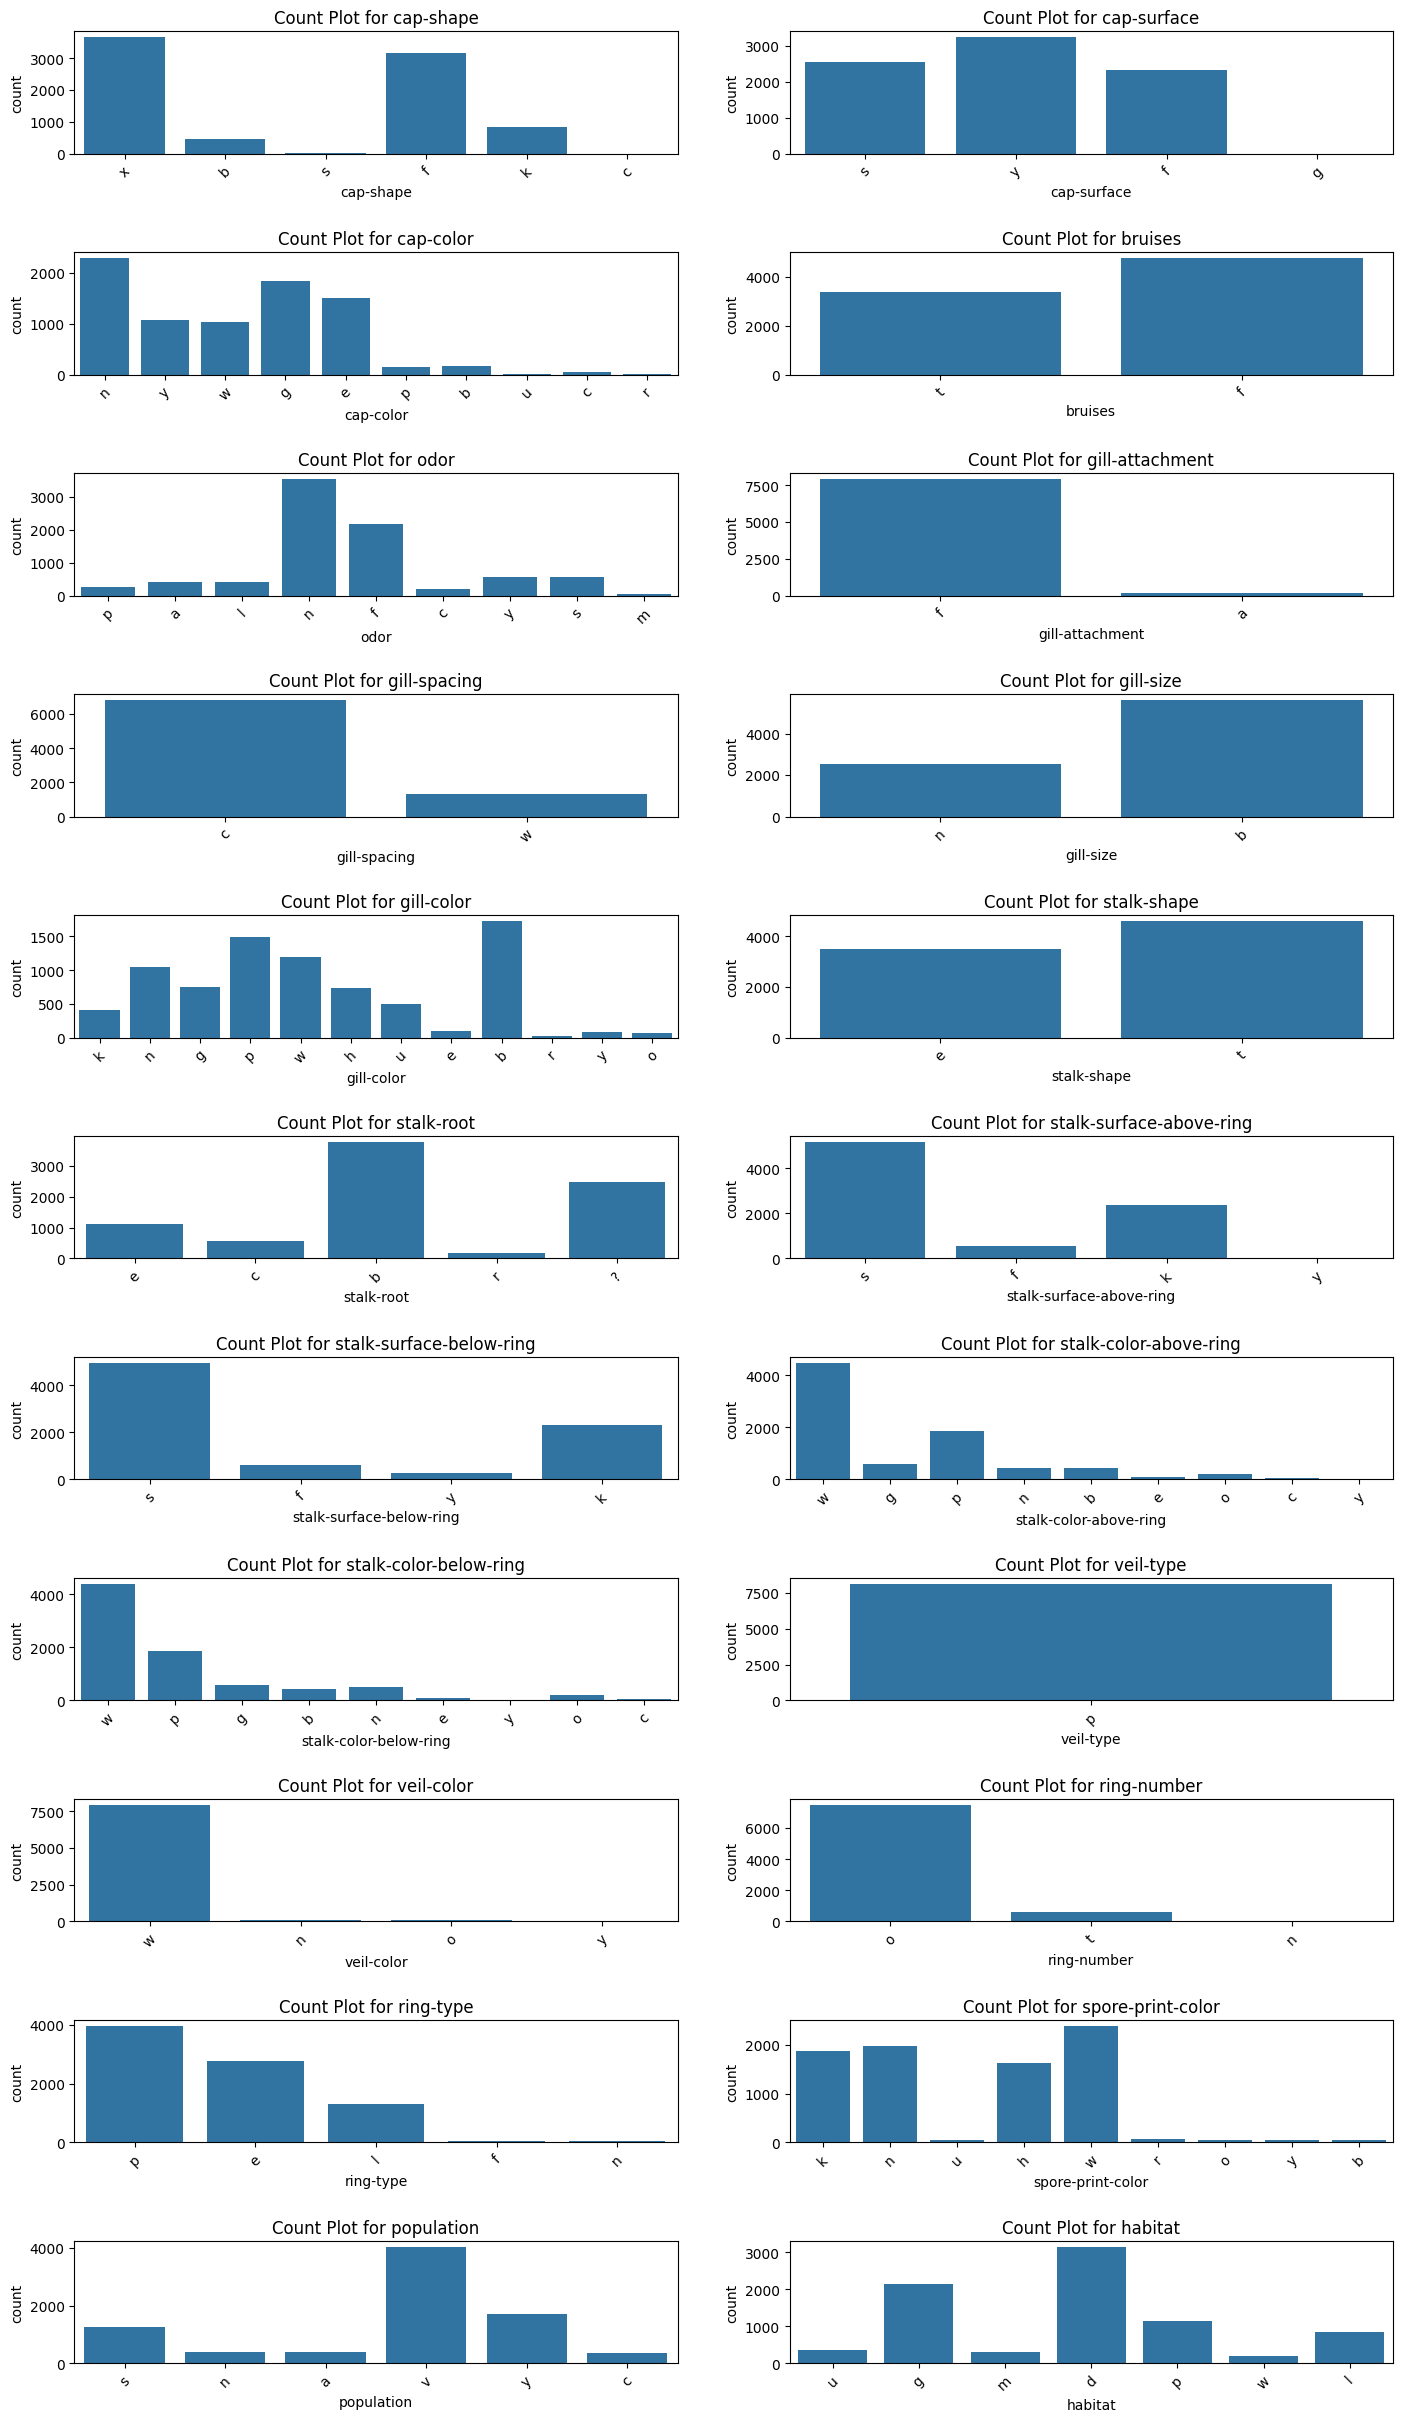

In [4]:
fig, axes = plt.subplots(nrows=11,ncols=2, figsize=(15,25))
plt.tight_layout(pad = 5.0)

for i, feature in enumerate(mush_df.columns.to_list()[1:]):
    row = i//2
    col = i%2
    
    sns.countplot(mush_df, x=feature, ax=axes[row, col])
    axes[row, col].set_title(f'Count Plot for {feature}')
    axes[row, col].tick_params(axis='x', rotation =45)

plt.show()

As we can see, the data has few features extremely rare or even absent, so the models will have difficulty learning certain features.

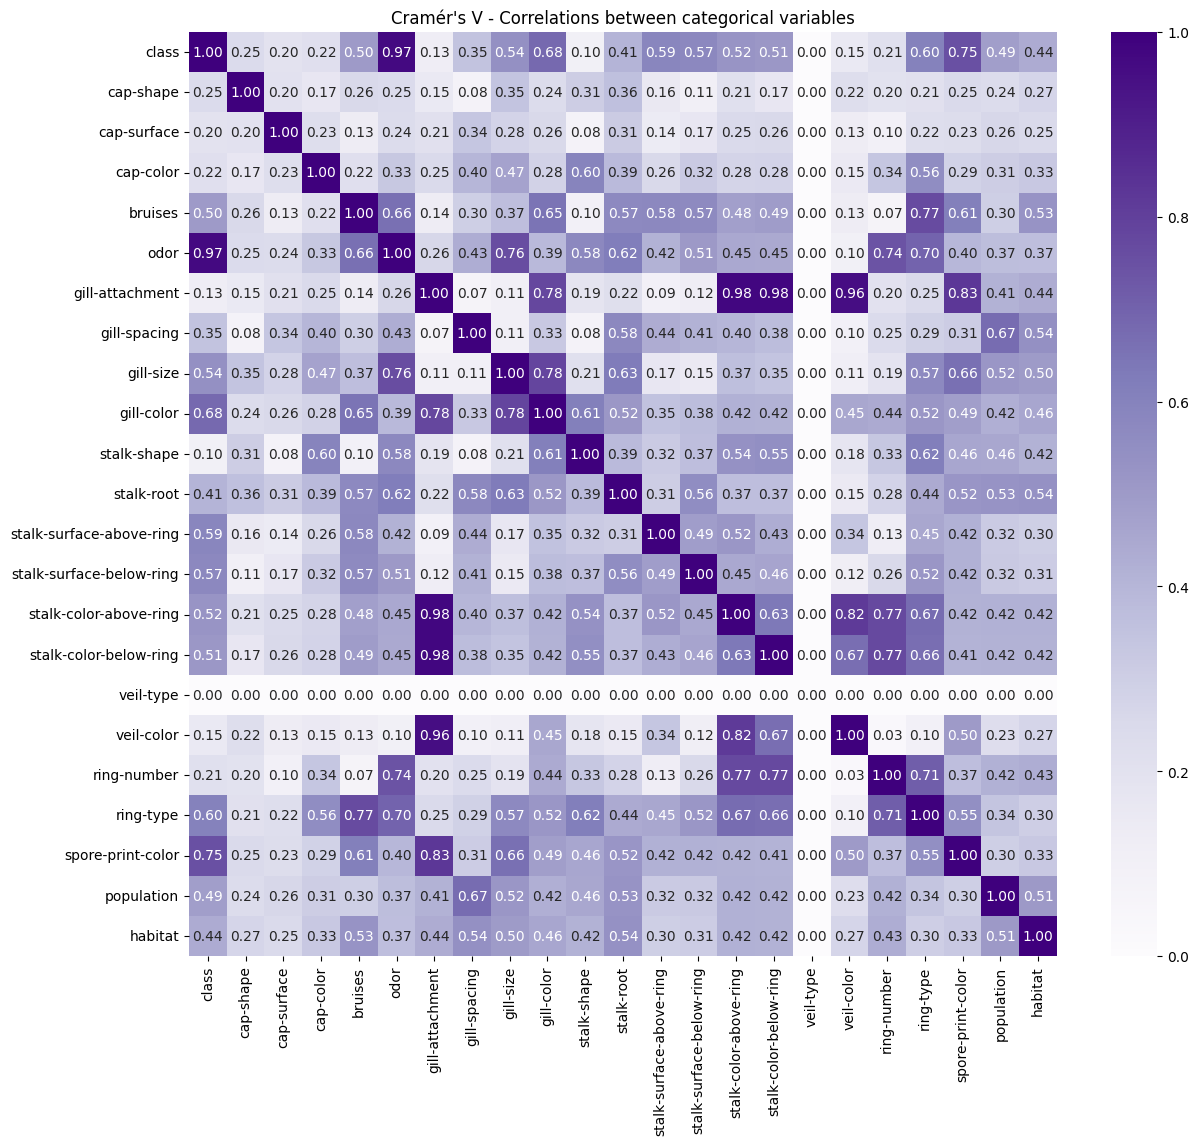

In [5]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape)
    
    if k <= 1:  # ← constant variable, indefinite association
        return 0.0
    
    return np.sqrt(chi2 / (n * (k - 1)))

cols = mush_df.columns
matrix = pd.DataFrame([[cramers_v(mush_df[c1], mush_df[c2]) 
                        for c2 in cols] for c1 in cols], 
                        index=cols, columns=cols)

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='Purples')
plt.title("Cramér's V - Correlations between categorical variables")
plt.show()

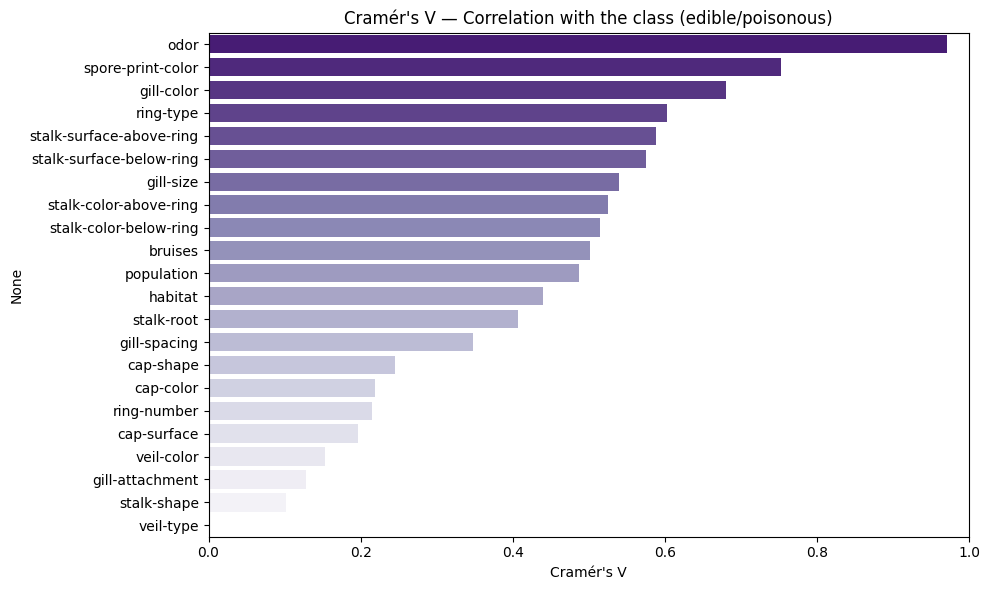

In [6]:
cramers_series = pd.Series([cramers_v(mush_df['class'], mush_df[col] ) for col in cols]
                           ,index=cols
                           ).drop('class').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cramers_series.values, y=cramers_series.index,
            hue=cramers_series.index, palette='Purples_r', legend=False)
plt.title("Cramér's V — Correlation with the class (edible/poisonous)")
plt.xlabel("Cramér's V")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

At first glance, the variables odor, spore print color, and gill color are the most correlated with the class

## Modelling

### Preprocessing

In [7]:
#In first we encode the Y (classes) variable.
le = LabelEncoder()
Y =le.fit_transform(mush_df['class']) #'e'-> 0 and 'p'-> 1

#Then we separate classes from data to create the X variable
mush_X = mush_df.drop('class', axis=1)

#We split the data set before encode the X variables to avoid data leackage
pre_X_train, pre_X_test, Y_train, Y_test = train_test_split(mush_X, Y, test_size=0.3, random_state=42, stratify=Y)

#We create an encoder to encode the data in a language understandable for models
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#Again to avoid data leakage we train the encoder only on the pre_X_train variable
encoder.fit(pre_X_train)

#We recreate a X variable which is the "sum" of X_train and X_test and we can now encode all of our X variable (X, X_train and X_test)
X = pd.DataFrame(encoder.transform(mush_X), columns=encoder.get_feature_names_out())

X_train = pd.DataFrame(encoder.transform(pre_X_train), columns=encoder.get_feature_names_out())
X_test = pd.DataFrame(encoder.transform(pre_X_test), columns=encoder.get_feature_names_out())



In the last cell we have process the data to make them understandable for our future models. Due to the LabelEncoder(), the Y variable contain 0 and 1 values which correspond to edible and poisonous, this is our target variable. Finally, we have put other features in a X variable that we have encode with the OneHotEncoder() which seperate each modalities of features and encode a 0 or a 1 if this modality is present in this sample. For exemple, the feature  bruises becomes bruises_f and bruises_t, the argument handle_unknown='ignore' is here to specify that we put a 0 if the modility is not present in the sample.

we paid particular attention to data leakage by training the encoder only on train sample. In this way our data are encode and process without our test sample.

## Different Classifier

 - Decision Tree
 - Gradient Boost
 - Ada Boost
 - Random Forest
 - Bagging
 - Neural network MLPClassifier

### Definition and first test above our classifiers

In [8]:
clf_Tree = DecisionTreeClassifier(random_state=42).fit(X_train, Y_train)

clf_GB = GradientBoostingClassifier(random_state=42).fit(X_train, Y_train)

clf_Ada = AdaBoostClassifier(random_state=42).fit(X_train, Y_train)

clf_Forest = RandomForestClassifier(random_state=42).fit(X_train, Y_train)

clf_Bag = BaggingClassifier(random_state=42).fit(X_train, Y_train)

clf_MLP = MLPClassifier(random_state=42)

models = {
    "Tree": clf_Tree,
    "Gradient Boost": clf_GB,
    "Ada Boost": clf_Ada,
    "Random Forest": clf_Forest,
    "Bagging": clf_Bag,
    'MLP': clf_MLP
}

In [9]:
def cross_result(X, Y, models, cv=5):
    results = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for name, model in models.items():

        scores  = cross_validate(model, X, Y, cv=skf, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

        results.append([
            name,
            scores['test_accuracy'].mean(),
            scores['test_accuracy'].std(),
            scores['test_precision_macro'].mean(),
            scores['test_recall_macro'].mean(),
            scores['test_f1_macro'].mean(),
            scores['test_f1_macro'].std()
        ])

    results_df = pd.DataFrame(results, columns=["Model",'Accuracy','Accuracy std','Precision','Recall', 'f1 score', 'f1 score std'])
    results_df = results_df.sort_values("Accuracy", ascending=False)

    return results_df



In [10]:
cross_result(X,Y, models)

,Model,Accuracy,Accuracy std,Precision,Recall,f1 score,f1 score std
0,Tree,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
3,Random Forest,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
5,MLP,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
1,Gradient Boost,0.999754,0.000492,0.999763,0.999745,0.999753,0.000493
4,Bagging,0.999754,0.000492,0.999763,0.999745,0.999753,0.000493
2,Ada Boost,0.998646,0.000718,0.998669,0.998622,0.998644,0.000719


The scores vary very little from one model to another. This dataset is very simple and linearly separable, so our models have no difficulty to fit with the data. Calculating the standard deviation allows us to measure the stability of the model across the different folds of the cross-validation. A high std is a potential sign of overfitting.

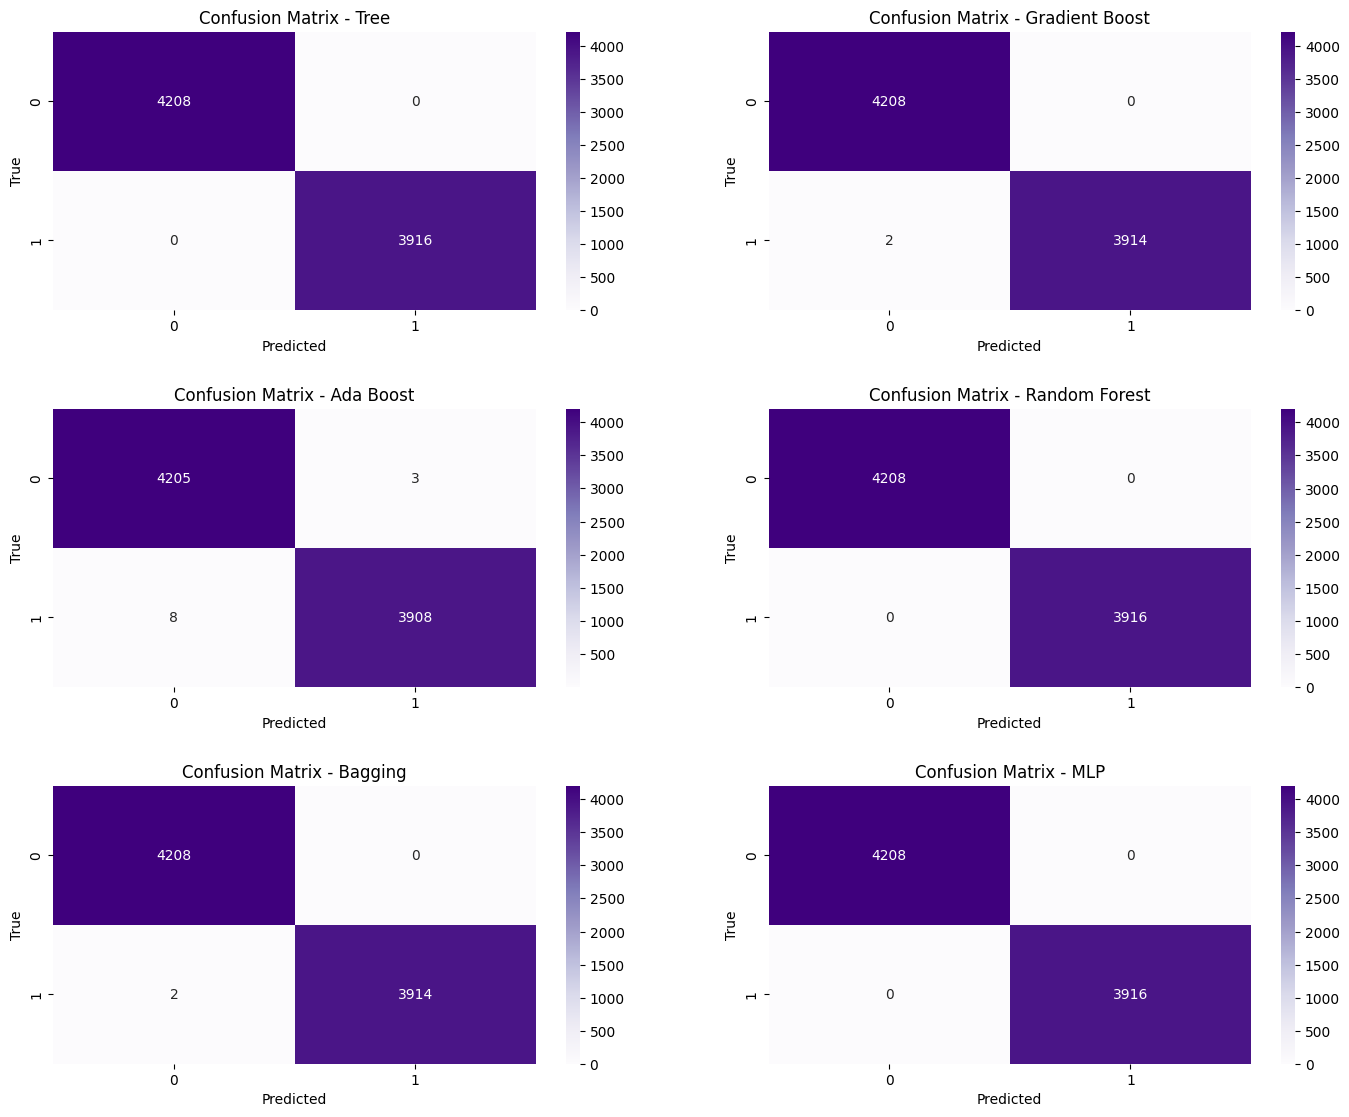

In [11]:
def confusion(X,Y, models, cv=5, n_row=3,n_col=2):
    fig, axes = plt.subplots(nrows=n_row,ncols=n_col, figsize=(15,12), squeeze=False)
    plt.tight_layout(pad = 5.0)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for i,(name, model) in enumerate(models.items()):
        row = i// n_col
        col = i%n_col

        y_pred = cross_val_predict(model, X, Y, cv=skf)
        cm = confusion_matrix(Y, y_pred)

        sns.heatmap(cm, annot=True, fmt='d',cmap='Purples', xticklabels=np.unique(Y), yticklabels=np.unique(Y), ax=axes[row, col])
        axes[row, col].set_xlabel("Predicted")
        axes[row, col].set_ylabel("True")
        axes[row, col].set_title(f"Confusion Matrix - {name}")


    for j in range(len(models), n_row * n_col):
        axes[j // n_col, j % n_col].set_visible(False)

    plt.show()

confusion(X,Y, models)


We choose Random Forest because 0 failed poisonous mushroom tests and thanks to this model we have access to plot_tree and feature_importances_.

### Optimisation of Random Forest

In [12]:
param_grid = {
    'n_estimators':[50,60,70,100,150,200,250,300,350,400],
    'criterion': ['gini','entropy','log_loss'],
    'max_depth':[None,10,20,30,40,50],
    'min_samples_split':[5,10,15,20,25,30],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2',None]
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = RandomizedSearchCV(clf_Forest, param_grid, cv=skf, scoring='accuracy',n_iter=10, n_jobs=-1, random_state=42)
grid_search.fit(X_train, Y_train)

print('Best hyperparameters: ', grid_search.best_params_)
print('Best cross-validation score: ', grid_search.best_score_)


Best hyperparameters:  {'n_estimators': 70, 'min_samples_split': 25, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'log_loss'}
Best cross-validation score:  1.0


We optimise the Random Forest model here. In fact it's unnecessary because the defult RandomForest fit well with our data, but it seems to have an impact on the prediction and the overfitting. Here a list of the paramaters we optimise:

**`n_estimators`** — The number of trees in the forest. The more trees, the more stable and accurate the model, but the slower it is to train. Beyond a certain threshold, the gains become negligible.

---

**`criterion`** — The function that measures the quality of a split at each node of the tree. `gini` measures leaf impurity, `entropy` measures information gain, `log_loss` uses log-likelihood. In practice, all three give very similar results.

---

**`max_depth`** — The maximum depth of each tree. `None` = the tree grows until all leaves are pure. Limiting the depth reduces overfitting but risks underfitting.

---

**`min_samples_split`** — The minimum number of samples required for a node to be split. A higher value forces the tree to be more conservative and reduces overfitting.

---

**`min_samples_leaf`** — The minimum number of samples required in a final leaf. If a split produces a leaf with fewer samples than this number, the split is rejected. This smooths the model.

---

**`max_features`** — The number of features considered at each split. `sqrt` = square root of the total number of features, `log2` = base-2 logarithm, `None` = all features. Reducing this number increases diversity between trees, which is the key principle of the Random Forest.

We used the StratifiedKFold() function to ensure of, by bad luck, not encountering a fold that might have very few poisonous mushrooms that will gives us a wrong score. The shuffle=True argument mix the data before cutting and the n_split=5 argument divide the data into 5 folds and train/evaluate 5 times like:

Fold 1 : [TEST ] [train] [train] [train] [train]

Fold 2 : [train] [TEST ] [train] [train] [train]

Fold 3 : [train] [train] [TEST ] [train] [train]

Fold 4 : [train] [train] [train] [TEST ] [train]

Fold 5 : [train] [train] [train] [train] [TEST ]



In [13]:
#Overfitting, underfiting ?
y_pred_test = grid_search.predict(X_test)
y_pred_train = grid_search.predict(X_train)

print(accuracy_score(Y_test,y_pred_test))
print(accuracy_score(Y_train,y_pred_train))


1.0
1.0


This test leads us to believe, by comparing its performance on the train and the test, that the model exhibits neither overfitting nor underfitting.

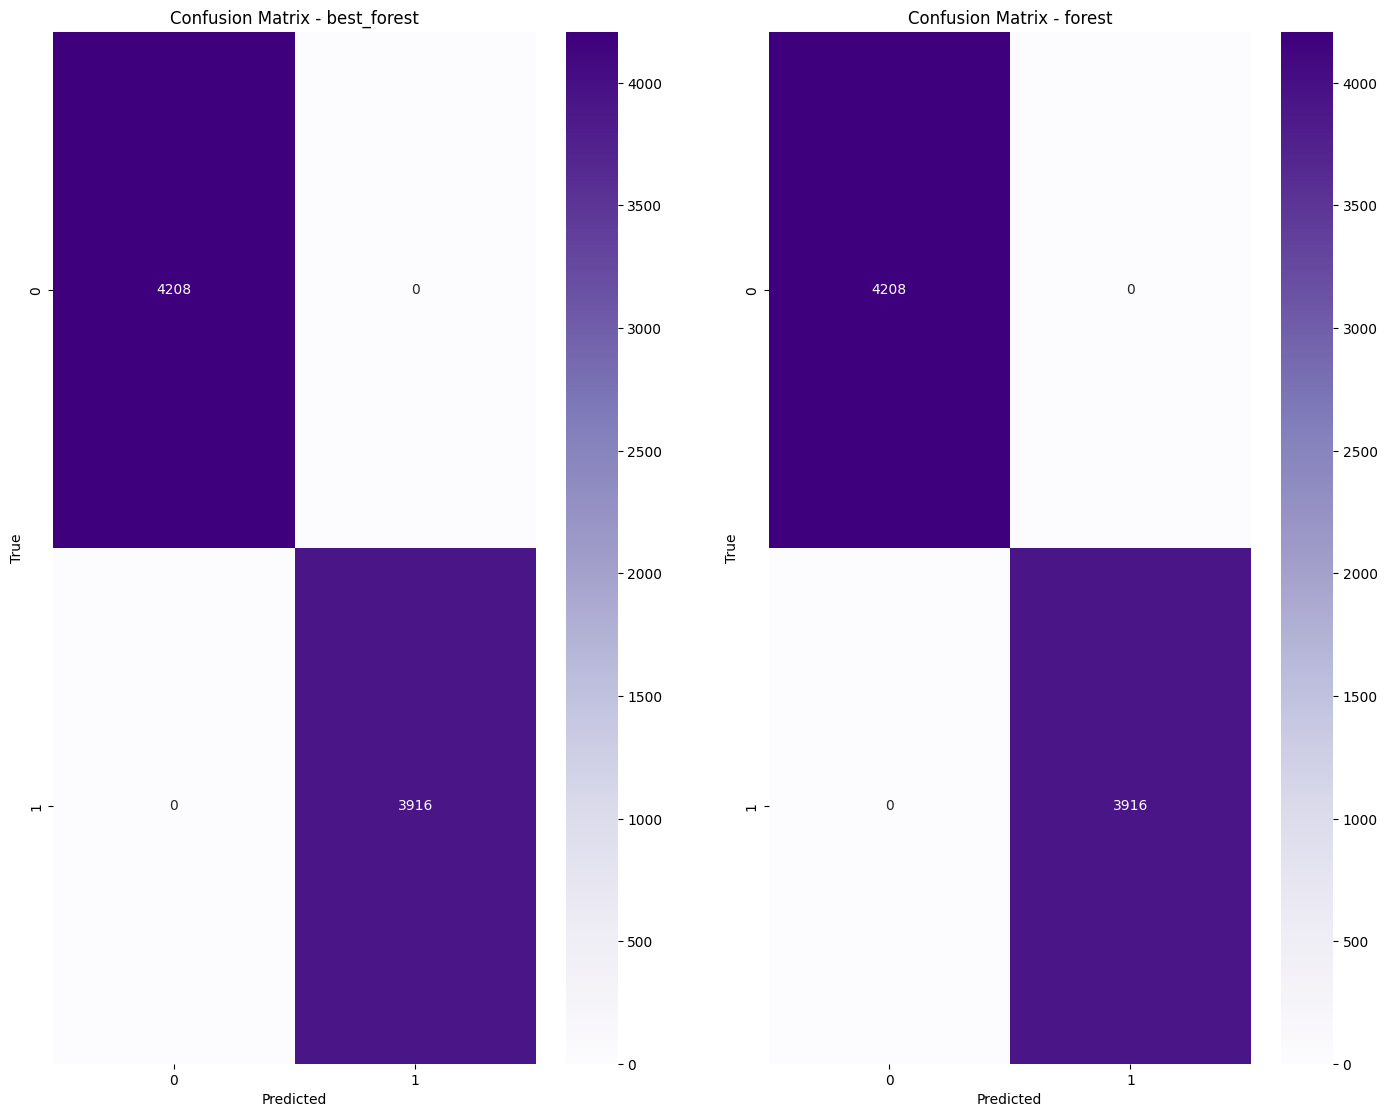

In [14]:
clf_Forest_b = grid_search.best_estimator_
confusion(X, Y, models = {'best_forest': clf_Forest_b, 'forest': clf_Forest}, n_col=2, n_row=1)

## Application

### Importance features and plot tree

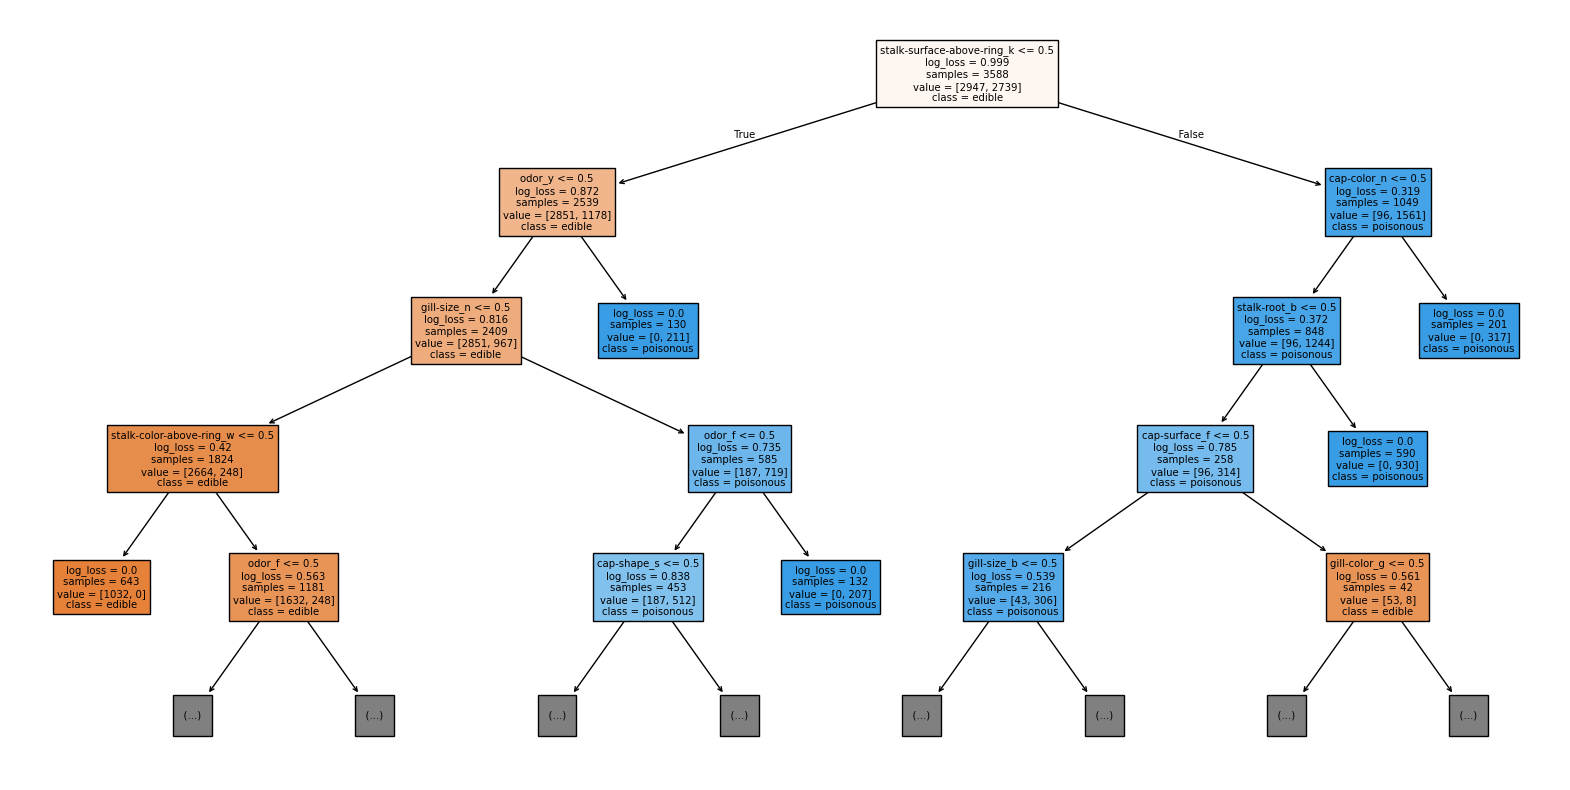

In [15]:
plt.figure(figsize=(20,10))
plot_tree(clf_Forest_b.estimators_[0], feature_names=X.columns, class_names=['edible','poisonous'], filled=True, max_depth=4)
plt.show()

How reading each nodes?

stalk-surface-above-ring_k <= 0.5       ← the question asked

log_loss = 0.999                        ← impurity of the node (close to 1 = mixed, 0 = pure)

samples = 3588                          ← number of observations that arrive here

value = [2947, 2739]                    ← [nb edible, nb poisonous]

class = edible                          ← majority class

In [16]:
importances =clf_Forest_b.feature_importances_ 
print(pd.Series(importances, index=X.columns).sort_values(ascending=False).head(20))

odor_n                        0.091033
gill-color_b                  0.070544
gill-size_b                   0.065832
odor_f                        0.060988
spore-print-color_h           0.038674
gill-size_n                   0.038613
stalk-surface-above-ring_s    0.032018
bruises_f                     0.031837
ring-type_l                   0.031081
bruises_t                     0.023145
stalk-surface-below-ring_k    0.023132
stalk-surface-above-ring_k    0.022521
ring-type_p                   0.021378
gill-spacing_w                0.019672
stalk-root_b                  0.018609
stalk-shape_e                 0.017415
spore-print-color_w           0.017379
population_v                  0.017200
spore-print-color_k           0.015230
spore-print-color_n           0.014445
dtype: float64


As we can see, the features have a relatively uniform importance, with the first four features standing out slightly: the odor (none and foul), the gill color (buff) and gill size (broad). A model that distributes importance is more robust.

### Prediction

Here we will work with a handmade sample and we will try to make prediction above it.

In [17]:
new_sample_mush = [{
                'cap-shape'     :'b'         , #bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
                'cap-surface'   :'f'       , #fibrous=f,grooves=g,scaly=y,smooth=s
                'cap-color'     :'c'         , #brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
                'bruises'       :'t'          , #bruises=t,no=f
                'odor'          :'a'              , #almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
                'gill-attachment':'a'   , #attached=a,descending=d,free=f,notched=n
                'gill-spacing'  :'c'      , #close=c,crowded=w,distant=d
                'gill-size'     :'b'         , #broad=b,narrow=n
                'gill-color'    :'b'        , #black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y
                'stalk-shape'   :'e'       , #enlarging=e,tapering=t
                'stalk-root'    :'b'        , #bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
                'stalk-surface-above-ring'  :'k'  , #fibrous=f,scaly=y,silky=k,smooth=s
                'stalk-surface-below-ring'  :'y'  , #fibrous=f,scaly=y,silky=k,smooth=s
                'stalk-color-above-ring'    :'c'    , #brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
                'stalk-color-below-ring'    :'y'    , #brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
                'veil-type'     :'p'         , #partial=p,universal=u
                'veil-color'    :'y'        , #brown=n,orange=o,white=w,yellow=y
                'ring-number'   :'n'       , #none=n,one=o,two=t
                'ring-type'     :'f'         , #cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
                'spore-print-color'         :'h' , #black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
                'population'    :'v'        , #abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
                'habitat'       :'l'             #grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d
    
}]

In [18]:
# Processing a new sample
sample = pd.DataFrame(new_sample_mush)

#Verifying that all modality in each features is correct
for col in sample.columns:
    val = sample[col].values[0]
    known = mush_df[col].unique()
    if val not in known:
        print(f"{col}: unknown value {val}. Valid values: {sorted(known)}")

# encode the new sample with our encoder and we reconstruct an understandable sample by encoding and adding the good name of each columns
X_new = pd.DataFrame(encoder.transform(sample), columns=encoder.get_feature_names_out())


In [19]:
#Print the probabilities and the final decision
classes = clf_Forest_b.classes_
proba = clf_Forest_b.predict_proba(X_new)[0]
print("Probabilities :")
for c, p in zip(classes, proba):
    label = "Edible" if c == 0 else "Poisonous"
    print(f"{label} : {p:.2%}")

pred = clf_Forest_b.predict(X_new)
if pred == 0:
    print("\n This mushroom is edible")
else: print("\n This mushroom is poisonous")


Probabilities :
Edible : 30.68%
Poisonous : 69.32%

 This mushroom is poisonous


In [20]:
# Find the rows in the dataset that are closest to your sample to gain confidence in our results
from sklearn.metrics import pairwise_distances
distances = pairwise_distances(X_new, X)
idx_plus_proches = distances[0].argsort()[:5]
print(mush_df.iloc[idx_plus_proches][['class']])

     class
7981     p
8114     p
7801     p
6668     p
7100     p


To improve the reliability of that prediction, we use a custom-built 'KNN' algorithm that searches for the nearest neighbor of our sample within the data. Here, all these neighbors are poisonous mirroring the prediction made on our sample.

## Pipeline

We will repeat the same process as before, but using a pipeline. The goal is to study how the Pipeline() function works.

In [21]:
from sklearn.pipeline import Pipeline

In [22]:
#Processing data as before
X_p = mush_df.drop('class', axis=1)
Y_p = le.fit_transform(mush_df['class'])


#Pipeline definition
pipeline = Pipeline([
    ('Preprocess', encoder),
    ('model', RandomForestClassifier(random_state=42))
])

X_train_p, X_test_p, Y_train_p, Y_test_p = train_test_split(X_p, Y_p,test_size=0.3, random_state=42, stratify=Y_p )

#Optimisation
param_grid_p = {
    'model__n_estimators':[50,60,70,100,150,200,250,300,350,400],
    'model__criterion': ['gini','entropy','log_loss'],
    'model__max_depth':[None,10,20,30,40,50],
    'model__min_samples_split':[5,10,15,20,25,30],
    'model__min_samples_leaf':[1,2,4],
    'model__max_features':['sqrt','log2',None]
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_p = RandomizedSearchCV(pipeline, param_grid_p, cv=skf, n_iter=10, scoring='accuracy', random_state=42)
grid_p.fit(X_train_p, Y_train_p)

print("Best params:", grid_p.best_params_)

pipeline = grid_p.best_estimator_
print("\n Accuracy score: ",accuracy_score(Y_test_p,pipeline.predict(X_test_p)))


Best params: {'model__n_estimators': 70, 'model__min_samples_split': 25, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30, 'model__criterion': 'log_loss'}

 Accuracy score:  1.0


To have the same result as before it's important to use the same encoder and the same paramaters grid.

In [23]:
#Check classes
print(clf_Forest_b.classes_)
print(pipeline.named_steps['model'].classes_)

[0 1]
[0 1]


Here we verify that the manual and the pipeline method have the same language such as 0 ← edible and 1 ← poisonous

In [24]:
#Prediction

classes_p = pipeline.named_steps['model'].classes_
sample_p = pd.DataFrame(new_sample_mush)
proba_p = pipeline.predict_proba(sample_p)[0]

print("Probabilities :")
for c, p in zip(classes_p, proba_p):
    label = "Edible" if c == 0 else "Poisonous"
    print(f"{label} : {p:.2%}")

pred_p = pipeline.predict(sample_p)
if pred_p == 0:
    print("\n This mushroom is edible")
else: print("\n This mushroom is poisonous")

Probabilities :
Edible : 30.68%
Poisonous : 69.32%

 This mushroom is poisonous


To conclude this little aperture on Pipeline, This fonction is very usefull to automise and securise against data leakage the modelisation of our data. The main advantage of the pipeline is to ensure that the encoder is fitted only on the train, never on the test. Moreover, All preprocessing and modeling are chained into a single object. There's no longer any need to manage transformations manually at each step. Finally, using a pipeline allows us to make predictions on a new sample with extreme simplicity you pass the raw data directly, the pipeline takes care of everything.

## Conclusion




### Results

This project aimed to classify mushrooms as edible or poisonous using machine learning models trained on 8124 observations and 22 categorical features.

After comparing six models (Decision Tree, Gradient Boosting, AdaBoost, Random Forest, Bagging, and MLP), all of them reached near-perfect accuracy on this dataset. We selected the **Random Forest** for its robustness, its resistance to overfitting, and its ability to provide interpretable outputs such as feature importances and tree visualization.

After hyperparameter optimization with `RandomizedSearchCV`, the final model achieved an accuracy of **1.0 on both train and test sets**, with no signs of overfitting.

### Key Findings

The most important features for predicting mushroom toxicity were:

- **odor** (none and foul) — the most discriminating feature by far
- **gill-color** (buff)
- **gill-size** (broad and narrow)
- **spore-print-color** (chocolate)

A mushroom with no odor and buff gills is very likely edible. A foul-smelling mushroom with chocolate spore print is a strong indicator of toxicity.

### What I Learned

- The importance of **splitting before encoding** to avoid data leakage
- How a **Pipeline** automates and secures the preprocessing workflow
- The difference between **overfitting and underfitting**, and how hyperparameters control model complexity
- How to **validate a prediction** on an unknown sample using probability scores and nearest neighbor search
- That a high accuracy is not always a sign of overfitting — sometimes the data is simply well structured and linearly separable